# Chạy trên Google Colab
Chạy cell dưới đây để mount Google Drive và tự động cấu hình các thư mục dự án.

In [1]:
# ===== MOUNT GOOGLE DRIVE =====
from google.colab import drive
drive.mount('/content/drive')

# ===== CÀI ĐẶT THƯ VIỆN & THIẾT LẬP ĐƯỜNG DẪN =====
# (Không cần cài thêm thư viện)

BASE_DIR = "/content/drive/MyDrive/TieuLuan_22130161"
DATA_DIR = f"{BASE_DIR}/data"
FN_DIR   = f"{BASE_DIR}/fn"
PKL_DIR  = f"{BASE_DIR}/pkl"
IMG_DIR  = f"{BASE_DIR}/image"

import os
os.makedirs(FN_DIR, exist_ok=True)
os.makedirs(PKL_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

print("Môi trường Colab đã sẵn sàng!")


Mounted at /content/drive
Môi trường Colab đã sẵn sàng!


# Notebook 01 — Mô hình Baseline: TF-IDF + Naive Bayes & SVM

**Mục tiêu:** Xây dựng các mô hình học máy truyền thống làm đường cơ sở (Baseline) để đối chuẩn với các mô hình học sâu:
- Trích xuất đặc trưng bằng **TF-IDF** (ngram 1–2, max 5000 từ)
- Huấn luyện **Multinomial Naive Bayes**
- Huấn luyện **Linear SVM (LinearSVC)**
- Đánh giá qua Accuracy, Precision, Recall, F1-Score
- Lưu mô hình để tái sử dụng và vẽ Ma trận nhầm lẫn

> **Yêu cầu tiên quyết:** Phải chạy xong `00_Tien_Xu_Ly.ipynb` trước để có dữ liệu trong thư mục `fn/`.

In [ ]:
# ===== CÀI ĐẶT THƯ VIỆN =====
# !pip install pandas scikit-learn matplotlib seaborn joblib


In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

FN_DIR = f"{BASE_DIR}/fn"
PKL_DIR = f"{BASE_DIR}/pkl"
IMG_DIR = f"{BASE_DIR}/image"
os.makedirs(PKL_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

print(" Import thư viện thành công!")


 Import thư viện thành công!


## 1. Nạp Dữ liệu Đã Tiền xử lý

In [3]:
train_df = pd.read_csv(os.path.join(FN_DIR, "cleaned_train.csv")).fillna('')
test_df  = pd.read_csv(os.path.join(FN_DIR, "cleaned_test.csv")).fillna('')

X_train, y_train = train_df['comment_cleaned'], train_df['label']
X_test,  y_test  = test_df['comment_cleaned'],  test_df['label']

print(f"Tập Train : {len(X_train):,} mẫu")
print(f"Tập Test  : {len(X_test):,} mẫu")
print(f"Phân bố nhãn (Train): {dict(y_train.value_counts().sort_index())}")


Tập Train : 11,426 mẫu
Tập Test  : 3,166 mẫu
Phân bố nhãn (Train): {0: np.int64(5325), 1: np.int64(458), 2: np.int64(5643)}


## 2. Trích xuất Đặc trưng TF-IDF

In [4]:
print("Đang trích xuất đặc trưng TF-IDF...")

# max_features=5000: Giữ lại 5000 từ/cụm từ quan trọng nhất
# ngram_range=(1,2): Sử dụng cả unigram và bigram
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)   # Học từ vựng từ tập Train
X_test_tfidf  = tfidf.transform(X_test)         # Chỉ biến đổi (không học) tập Test

# Lưu vectorizer để dùng ở bước Predict
joblib.dump(tfidf, os.path.join(PKL_DIR, "tfidf_vectorizer.pkl"))

print(f"Kích thước ma trận Train: {X_train_tfidf.shape}")
print(f"Kích thước ma trận Test : {X_test_tfidf.shape}")
print(f"Đã lưu TfidfVectorizer → {PKL_DIR}/tfidf_vectorizer.pkl")


Đang trích xuất đặc trưng TF-IDF...
Kích thước ma trận Train: (11426, 5000)
Kích thước ma trận Test : (3166, 5000)
Đã lưu TfidfVectorizer → /content/drive/MyDrive/TieuLuan_22130161/pkl/tfidf_vectorizer.pkl


## 3. Huấn luyện Mô hình Naive Bayes

In [5]:
print("Đang huấn luyện Multinomial Naive Bayes...")

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
nb_acc  = accuracy_score(y_test, nb_pred)

joblib.dump(nb_model, os.path.join(PKL_DIR, "naive_bayes_model.pkl"))

print(f"Test Accuracy: {nb_acc*100:.2f}%")
print(f"Đã lưu mô hình → {PKL_DIR}/naive_bayes_model.pkl")
print()
label_names = ['Tieu cuc (0)', 'Trung tinh (1)', 'Tich cuc (2)']
print(classification_report(y_test, nb_pred, target_names=label_names, digits=4))


Đang huấn luyện Multinomial Naive Bayes...
Test Accuracy: 86.36%
Đã lưu mô hình → /content/drive/MyDrive/TieuLuan_22130161/pkl/naive_bayes_model.pkl

                precision    recall  f1-score   support

  Tieu cuc (0)     0.8148    0.9524    0.8783      1409
Trung tinh (1)     0.6667    0.0120    0.0235       167
  Tich cuc (2)     0.9169    0.8742    0.8950      1590

      accuracy                         0.8636      3166
     macro avg     0.7995    0.6129    0.5989      3166
  weighted avg     0.8583    0.8636    0.8416      3166



## 4. Huấn luyện Mô hình SVM

In [6]:
from sklearn.model_selection import GridSearchCV

print("Đang chạy Grid Search với 5-Fold Cross Validation cho SVM...")

# Khảo sát dải rộng của tham số C và max_iter theo góp ý của phản biện
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [1000, 2000]
}

# Thiết lập Grid Search với 5-Fold Cross Validation
grid_search = GridSearchCV(
    LinearSVC(dual=False, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_tfidf, y_train)

print(f"Siêu tham số tối ưu tìm được: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_*100:.2f}%")

# Lưu mô hình tối ưu nhất
svm_model = grid_search.best_estimator_
joblib.dump(svm_model, os.path.join(PKL_DIR, "svm_best_model.pkl"))

# Dự đoán trên tập Test
svm_pred = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"Test Accuracy: {svm_acc*100:.2f}%")
print(f"Đã lưu mô hình -> {PKL_DIR}/svm_best_model.pkl")
print()
print(classification_report(y_test, svm_pred, target_names=label_names, digits=4))


Đang chạy Grid Search với 5-Fold Cross Validation cho SVM...
Siêu tham số tối ưu tìm được: {'C': 1, 'max_iter': 1000}
Best Cross-Validation Score: 90.81%
Test Accuracy: 88.82%
Đã lưu mô hình -> /content/drive/MyDrive/TieuLuan_22130161/pkl/svm_best_model.pkl

                precision    recall  f1-score   support

  Tieu cuc (0)     0.8691    0.9468    0.9062      1409
Trung tinh (1)     0.4889    0.1317    0.2075       167
  Tich cuc (2)     0.9180    0.9157    0.9169      1590

      accuracy                         0.8882      3166
     macro avg     0.7587    0.6647    0.6769      3166
  weighted avg     0.8736    0.8882    0.8747      3166



## 5. Vẽ Ma trận Nhầm lẫn (Confusion Matrix)

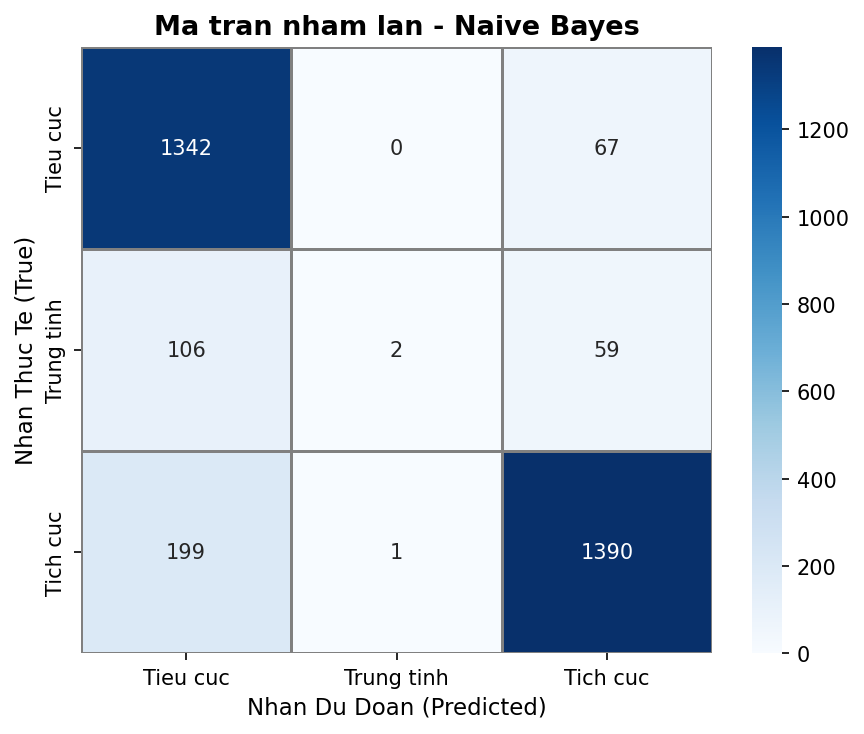

Đã lưu ảnh → /content/drive/MyDrive/TieuLuan_22130161/image/cm_naive_bayes.png


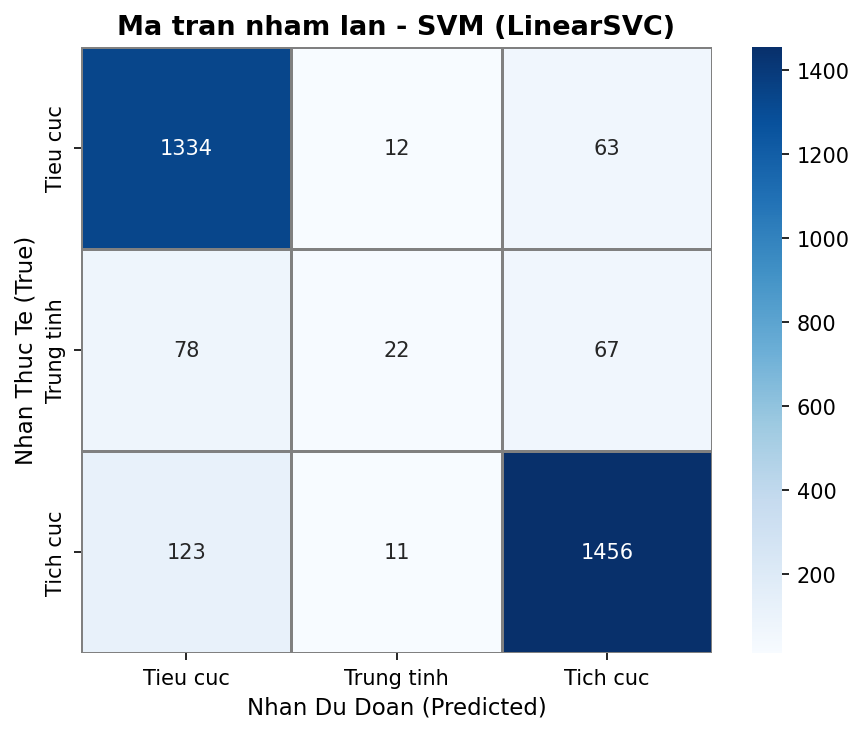

Đã lưu ảnh → /content/drive/MyDrive/TieuLuan_22130161/image/cm_svm.png


In [7]:
def plot_cm(y_true, y_pred, model_name, filename):
    cm = confusion_matrix(y_true, y_pred)
    class_names = ['Tieu cuc', 'Trung tinh', 'Tich cuc']
    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='gray')
    plt.xlabel('Nhan Du Doan (Predicted)', fontsize=11)
    plt.ylabel('Nhan Thuc Te (True)', fontsize=11)
    plt.title(f'Ma tran nham lan - {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(IMG_DIR, filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Đã lưu ảnh → {save_path}")

plot_cm(y_test, nb_pred,  "Naive Bayes",   "cm_naive_bayes.png")
plot_cm(y_test, svm_pred, "SVM (LinearSVC)","cm_svm.png")


## 6. Tổng hợp Kết quả Baseline

In [8]:
print("=" * 55)
print(f"{'Mô hình':<25} {'Accuracy':>10} {'F1-Macro':>10}")
print("-" * 55)
from sklearn.metrics import f1_score
print(f"{'Multinomial Naive Bayes':<25} {nb_acc*100:>9.2f}% {f1_score(y_test,nb_pred,average='macro')*100:>9.2f}%")
print(f"{'Linear SVM (LinearSVC)':<25} {svm_acc*100:>9.2f}% {f1_score(y_test,svm_pred,average='macro')*100:>9.2f}%")
print("=" * 55)


Mô hình                     Accuracy   F1-Macro
-------------------------------------------------------
Multinomial Naive Bayes       86.36%     59.89%
Linear SVM (LinearSVC)        88.82%     67.69%
